In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

warnings.filterwarnings("ignore")

# Machine Learning libraries
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

# Regression models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor
)

# Evaluation metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load the dataset

df = pd.read_csv("C:\\Users\\ABHISHEK\\Documents\\Data Science\\CONTENT MONETIZATION MODELER_project\\youtube_ad_revenue_dataset(1).csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 122400
Number of columns: 12


In [5]:
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,50:41.0,9936,1221.0,320.0,26497.21418,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,50:41.0,10017,642.0,346.0,15209.74744,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,50:41.0,10097,1979.0,187.0,57332.65850,26.200634,240534,Education,TV,CA,360.134007
3,vid_4078,50:41.0,10034,1191.0,242.0,31334.51777,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,50:41.0,9889,1858.0,477.0,15665.66643,6.635854,42030,Education,Mobile,CA,165.514388


In [6]:
df.tail()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
122395,vid_2902,50:41.0,9853,1673.0,147.0,42075.70489,25.490195,210818,Education,Tablet,US,280.986396
122396,vid_3890,50:41.0,10128,1709.0,63.0,57563.70304,16.229133,878860,Music,Desktop,UK,354.612981
122397,vid_3934,50:41.0,10267,700.0,NaN,27549.71466,23.822365,576756,Tech,Tablet,CA,203.643106
122398,vid_4260,50:41.0,10240,1616.0,106.0,56967.38438,7.753099,585138,Music,Mobile,UK,351.525811
122399,vid_1056,50:41.0,9931,770.0,NaN,38466.83714,27.305703,517587,Tech,TV,CA,253.842824


In [7]:
df.sample(5, random_state=42)

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
20821,vid_1308,50:41.0,9866,554.0,293.0,29206.22355,22.119651,718514,Lifestyle,Desktop,DE,203.657208
43046,vid_4283,50:41.0,9925,1407.0,492.0,17817.86404,9.687818,600652,Entertainment,TV,IN,168.354889
111132,vid_4712,50:41.0,9856,562.0,154.0,34471.74397,23.528092,87982,Tech,TV,CA,226.178045
109329,vid_3410,50:41.0,10084,1510.0,171.0,33510.38548,9.660516,709660,Gaming,Desktop,UK,239.419451
43598,vid_1778,50:41.0,10093,595.0,467.0,28833.57151,23.991990,702388,Tech,Tablet,DE,206.778367


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


In [9]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['video_id', 'date', 'views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'category', 'device', 'country', 'ad_revenue_usd']


In [10]:
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105560,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320565,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990340,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670090,29.999799,999997.000000,382.768254


In [11]:
df.describe(include="object")

,video_id,date,category,device,country
count,122400,122400,122400,122400,122400
unique,5000,1,6,4,6
top,vid_3033,50:41.0,Education,TV,CA
freq,47,122400,20514,30646,20603


In [12]:
missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_table = missing_table.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_table

,Missing Values,Missing Percentage
likes,6117,4.997549
comments,6112,4.993464
watch_time_minutes,6105,4.987745
video_id,0,0.000000
date,0,0.000000
views,0,0.000000
video_length_minutes,0,0.000000
subscribers,0,0.000000
category,0,0.000000
device,0,0.000000


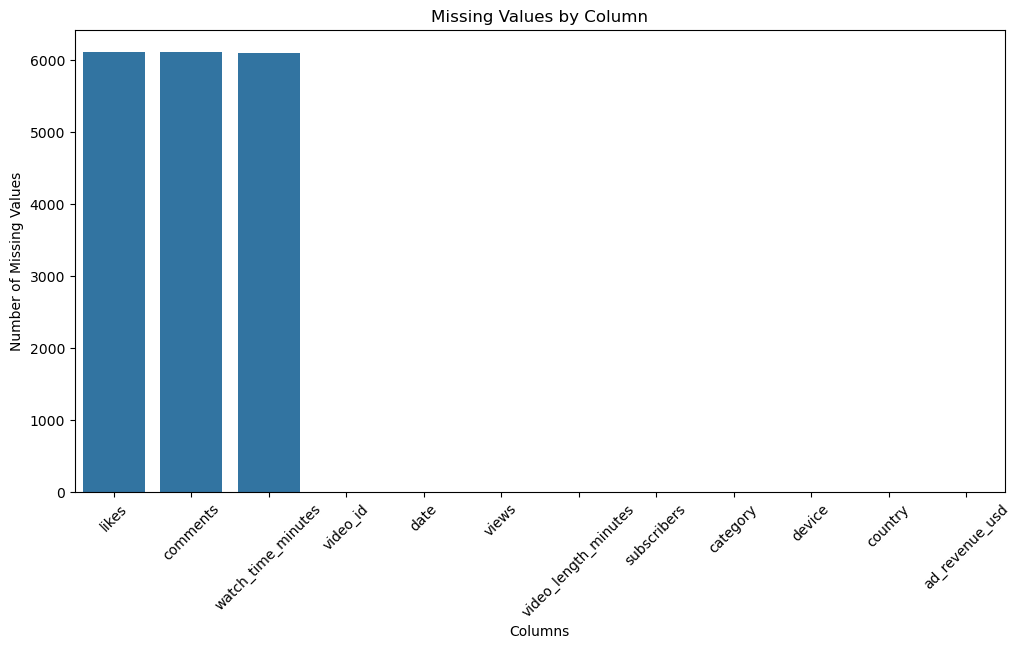

In [13]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=missing_table.index,
    y=missing_table["Missing Values"]
)

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.show()

In [14]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 2400


In [15]:
df = df.drop_duplicates()#remove duplicates

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (120000, 12)


In [16]:
print("Categories:")
print(df["category"].unique())

print("\nDevices:")
print(df["device"].unique())

print("\nCountries:")
print(df["country"].unique())

Categories:
['Entertainment' 'Gaming' 'Education' 'Music' 'Tech' 'Lifestyle']

Devices:
['TV' 'Tablet' 'Mobile' 'Desktop']

Countries:
['IN' 'CA' 'UK' 'US' 'DE' 'AU']


In [17]:
target = "ad_revenue_usd"

print("Target variable:", target)
print("Target data type:", df[target].dtype)

Target variable: ad_revenue_usd
Target data type: float64


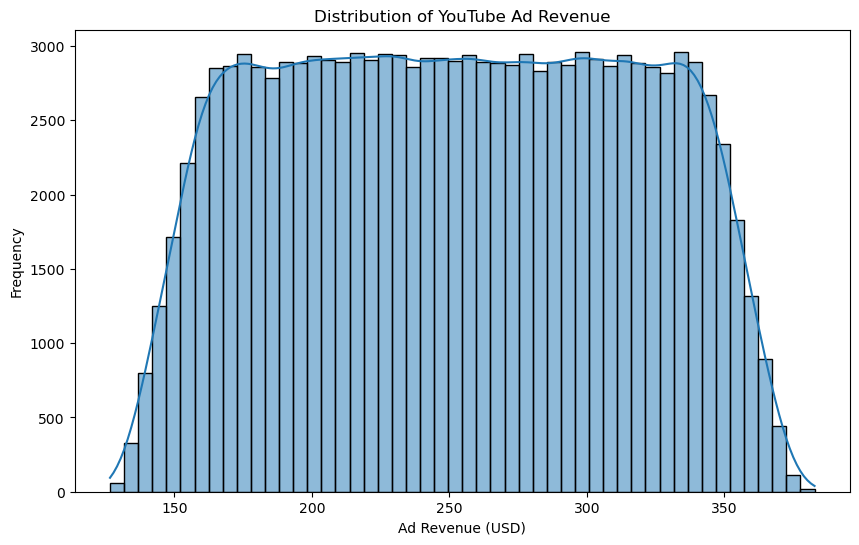

In [18]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["ad_revenue_usd"],
    bins=50,
    kde=True
)

plt.title("Distribution of YouTube Ad Revenue")
plt.xlabel("Ad Revenue (USD)")
plt.ylabel("Frequency")

plt.show()

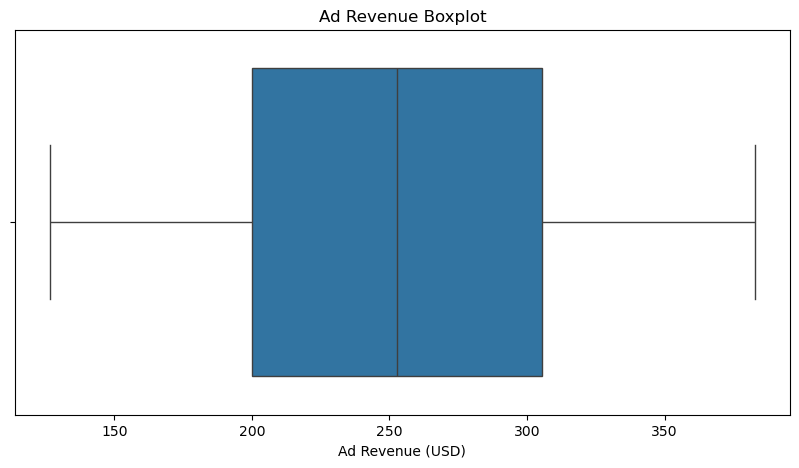

In [19]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["ad_revenue_usd"]
)

plt.title("Ad Revenue Boxplot")
plt.xlabel("Ad Revenue (USD)")

plt.show()

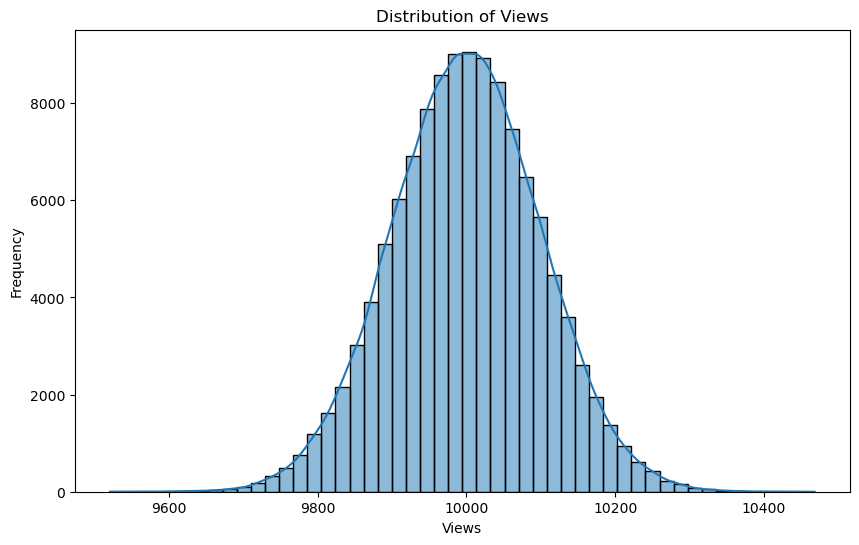

In [20]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["views"],
    bins=50,
    kde=True
)

plt.title("Distribution of Views")
plt.xlabel("Views")
plt.ylabel("Frequency")

plt.show()

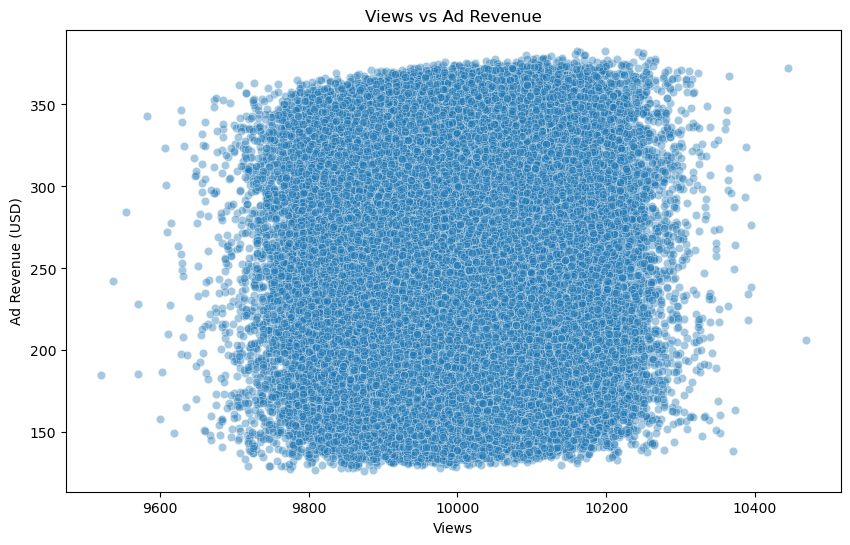

In [21]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="views",
    y="ad_revenue_usd",
    alpha=0.4
)

plt.title("Views vs Ad Revenue")
plt.xlabel("Views")
plt.ylabel("Ad Revenue (USD)")

plt.show()

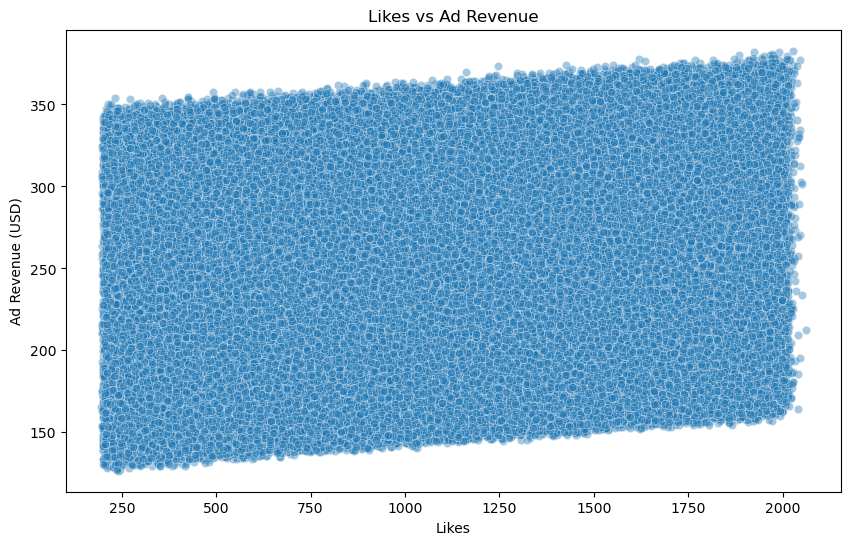

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="likes",
    y="ad_revenue_usd",
    alpha=0.4
)

plt.title("Likes vs Ad Revenue")
plt.xlabel("Likes")
plt.ylabel("Ad Revenue (USD)")

plt.show()

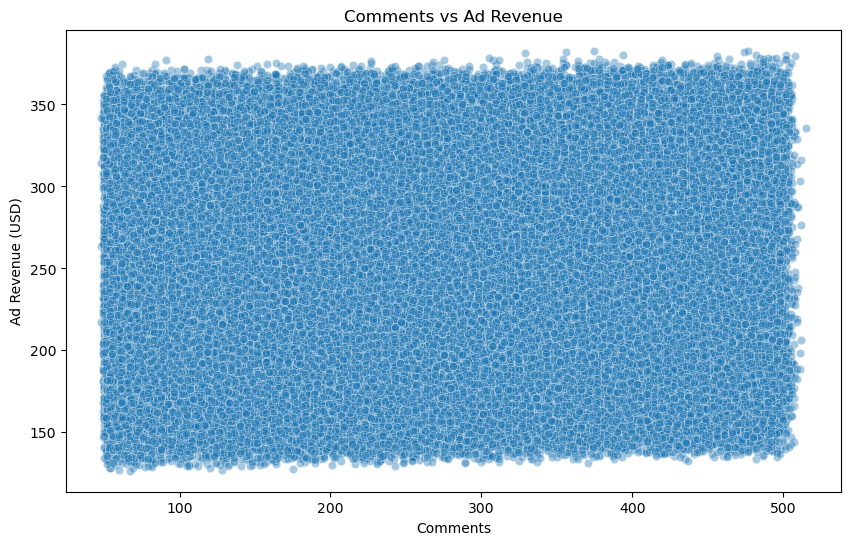

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="comments",
    y="ad_revenue_usd",
    alpha=0.4
)

plt.title("Comments vs Ad Revenue")
plt.xlabel("Comments")
plt.ylabel("Ad Revenue (USD)")

plt.show()

In [24]:
category_revenue = (
    df.groupby("category")["ad_revenue_usd"]
    .mean()
    .sort_values(ascending=False)
)

print(category_revenue)

category
Tech             253.458882
Gaming           253.426887
Education        252.564162
Music            252.477374
Entertainment    252.397546
Lifestyle        251.936934
Name: ad_revenue_usd, dtype: float64


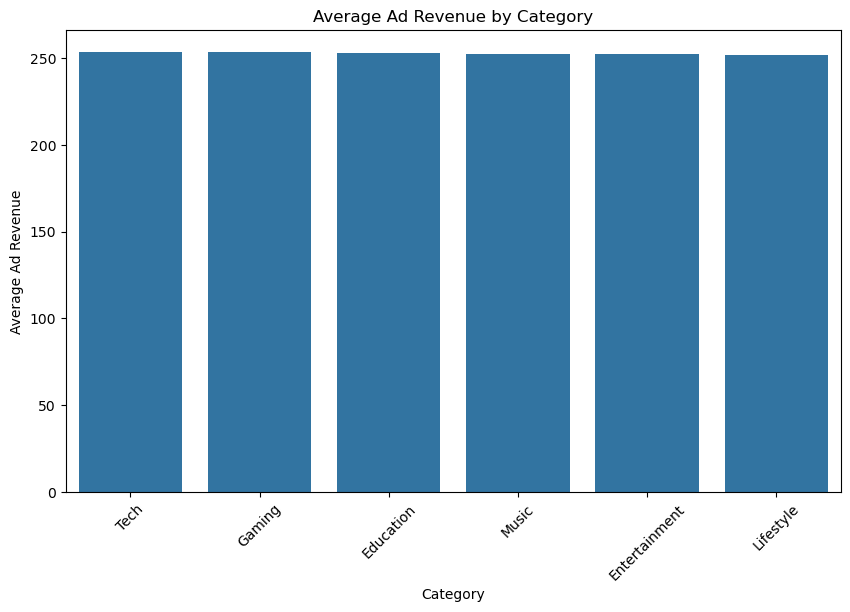

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title("Average Ad Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Average Ad Revenue")

plt.xticks(rotation=45)

plt.show()

In [26]:
device_revenue = (
    df.groupby("device")["ad_revenue_usd"]
    .mean()
    .sort_values(ascending=False)
)

print(device_revenue)

device
Mobile     253.243583
Tablet     252.994347
TV         252.332093
Desktop    252.277030
Name: ad_revenue_usd, dtype: float64


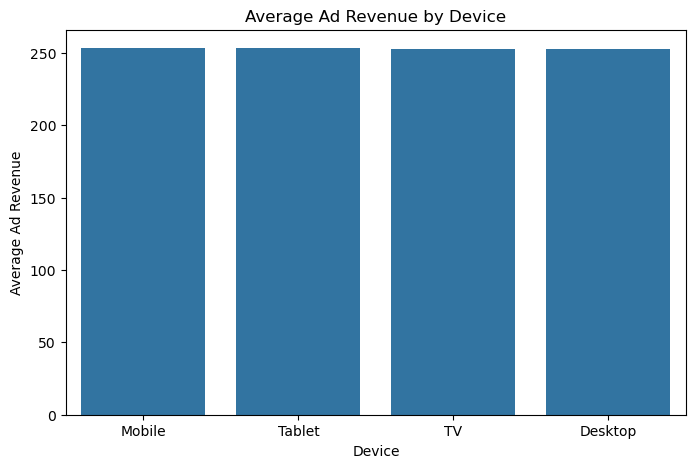

In [27]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=device_revenue.index,
    y=device_revenue.values
)

plt.title("Average Ad Revenue by Device")
plt.xlabel("Device")
plt.ylabel("Average Ad Revenue")

plt.show()

In [28]:
country_revenue = (
    df.groupby("country")["ad_revenue_usd"]
    .mean()
    .sort_values(ascending=False)
)

print(country_revenue)

country
US    253.178831
CA    252.834975
DE    252.749160
UK    252.555923
IN    252.493557
AU    252.461385
Name: ad_revenue_usd, dtype: float64


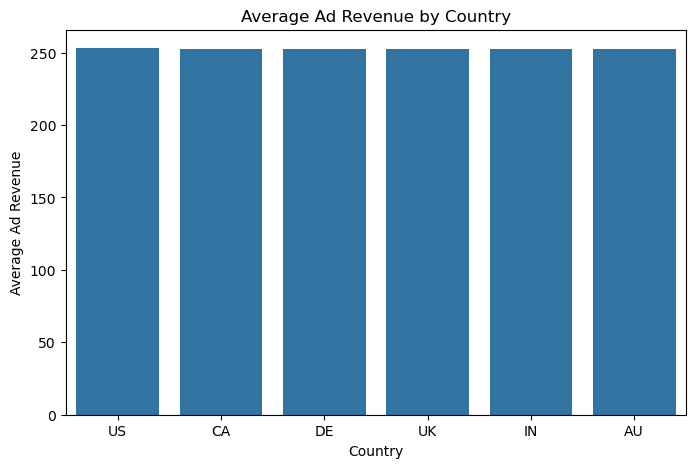

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=country_revenue.index,
    y=country_revenue.values
)

plt.title("Average Ad Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Average Ad Revenue")

plt.show()

In [30]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

correlation = df[numeric_columns].corr()

correlation

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
views,1.000000,0.015607,0.018597,0.026737,0.001171,0.000750,0.037942
likes,0.015607,1.000000,-0.002138,0.002864,0.001817,0.003622,0.146269
comments,0.018597,-0.002138,1.000000,-0.000749,-0.002233,-0.001564,0.034494
watch_time_minutes,0.026737,0.002864,-0.000749,1.000000,-0.000398,0.004734,0.988869
video_length_minutes,0.001171,0.001817,-0.002233,-0.000398,1.000000,0.002015,0.000364
subscribers,0.000750,0.003622,-0.001564,0.004734,0.002015,1.000000,0.005065
ad_revenue_usd,0.037942,0.146269,0.034494,0.988869,0.000364,0.005065,1.000000


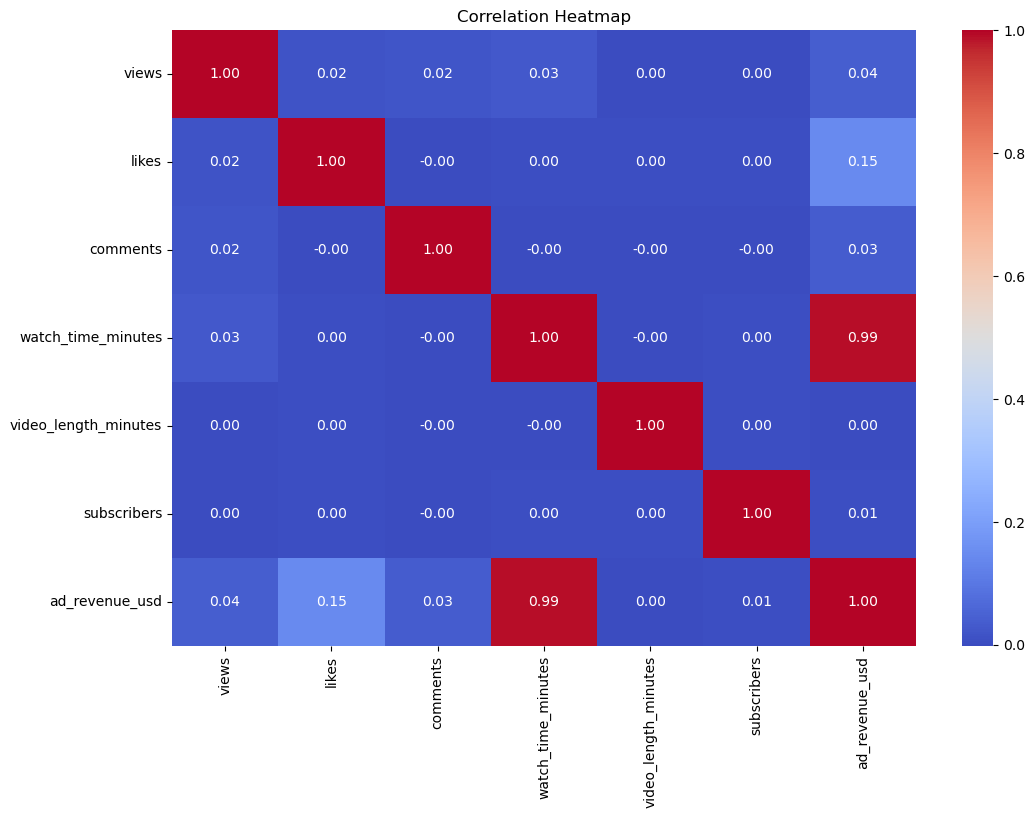

In [31]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [32]:
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                   6000
comments                6000
watch_time_minutes      6000
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [33]:
df["engagement_rate"] = (
    (df["likes"] + df["comments"]) /
    df["views"].replace(0, np.nan)
)

df["engagement_rate"] = (
    df["engagement_rate"]
    .replace([np.inf, -np.inf], np.nan)
)

In [34]:
df["watch_time_per_minute"] = (
    df["watch_time_minutes"] /
    df["video_length_minutes"].replace(0, np.nan)
)

df["watch_time_per_minute"] = (
    df["watch_time_per_minute"]
    .replace([np.inf, -np.inf], np.nan)
)

In [35]:
df["views_per_subscriber"] = (
    df["views"] /
    df["subscribers"].replace(0, np.nan)
)

df["views_per_subscriber"] = (
    df["views_per_subscriber"]
    .replace([np.inf, -np.inf], np.nan)
)

In [36]:
df[
    [
        "views",
        "likes",
        "comments",
        "engagement_rate",
        "watch_time_per_minute",
        "views_per_subscriber",
        "ad_revenue_usd"
    ]
].head()

,views,likes,comments,engagement_rate,watch_time_per_minute,views_per_subscriber,ad_revenue_usd
0,9936,1221.0,320.0,0.155093,9257.844017,0.043563,203.178237
1,10017,642.0,346.0,0.098632,640.732306,0.013610,140.880508
2,10097,1979.0,187.0,0.214519,2188.216490,0.041977,360.134007
3,10034,1191.0,242.0,0.142814,2662.159087,0.023094,224.638261
4,9889,1858.0,477.0,0.236121,2360.761215,0.235284,165.514388


In [37]:
df.isnull().sum()

video_id                     0
date                         0
views                        0
likes                     6000
comments                  6000
watch_time_minutes        6000
video_length_minutes         0
subscribers                  0
category                     0
device                       0
country                      0
ad_revenue_usd               0
engagement_rate          11696
watch_time_per_minute     6000
views_per_subscriber         0
dtype: int64

In [38]:
# Target
y = df["ad_revenue_usd"]

# Features
X = df.drop(
    columns=["ad_revenue_usd"]
)

In [39]:
columns_to_drop = [
    "video_id",
    "date"
]

X = X.drop(
    columns=columns_to_drop,
    errors="ignore"
)

print(X.columns.tolist())

['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'category', 'device', 'country', 'engagement_rate', 'watch_time_per_minute', 'views_per_subscriber']


In [40]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (120000, 12)
Target shape: (120000,)


In [41]:
numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical features:")
print(numerical_features)

Numerical features:
['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'engagement_rate', 'watch_time_per_minute', 'views_per_subscriber']


In [42]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

Categorical features:
['category', 'device', 'country']


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 96000
Testing rows: 24000


In [44]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [45]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [47]:
models = {

    "Linear Regression":
        LinearRegression(),

    "Ridge Regression":
        Ridge(alpha=1.0),

    "Lasso Regression":
        Lasso(
            alpha=0.001,
            max_iter=5000
        ),

    "Decision Tree":
        DecisionTreeRegressor(
            max_depth=15,
            random_state=42
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        )
}

print("Number of models:", len(models))

Number of models: 5


In [48]:
results = []

trained_models = {}

for model_name, model in models.items():

    print("\n" + "=" * 50)
    print("Training:", model_name)
    print("=" * 50)

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    # Train
    pipeline.fit(
        X_train,
        y_train
    )

    # Prediction
    predictions = pipeline.predict(
        X_test
    )

    # Metrics
    r2 = r2_score(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    results.append({
        "Model": model_name,
        "R2 Score": r2,
        "RMSE": rmse,
        "MAE": mae
    })

    trained_models[
        model_name
    ] = pipeline

    print("R² Score:", round(r2, 4))
    print("RMSE:", round(rmse, 4))
    print("MAE:", round(mae, 4))


Training: Linear Regression
R² Score: 0.9526
RMSE: 13.4791
MAE: 3.1082

Training: Ridge Regression
R² Score: 0.9526
RMSE: 13.4791
MAE: 3.1082

Training: Lasso Regression
R² Score: 0.9526
RMSE: 13.479
MAE: 3.1045

Training: Decision Tree
R² Score: 0.9396
RMSE: 15.2073
MAE: 4.2912

Training: Random Forest
R² Score: 0.9512
RMSE: 13.6757
MAE: 3.4825


In [49]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df

,Model,R2 Score,RMSE,MAE
2,Lasso Regression,0.952582,13.478959,3.104540
0,Linear Regression,0.952581,13.479109,3.108184
1,Ridge Regression,0.952581,13.479110,3.108231
4,Random Forest,0.951187,13.675670,3.482536
3,Decision Tree,0.939642,15.207300,4.291194


In [50]:
results_display = results_df.copy()

results_display["R2 Score"] = (
    results_display["R2 Score"]
    .round(4)
)

results_display["RMSE"] = (
    results_display["RMSE"]
    .round(4)
)

results_display["MAE"] = (
    results_display["MAE"]
    .round(4)
)

results_display

,Model,R2 Score,RMSE,MAE
2,Lasso Regression,0.9526,13.4790,3.1045
0,Linear Regression,0.9526,13.4791,3.1082
1,Ridge Regression,0.9526,13.4791,3.1082
4,Random Forest,0.9512,13.6757,3.4825
3,Decision Tree,0.9396,15.2073,4.2912


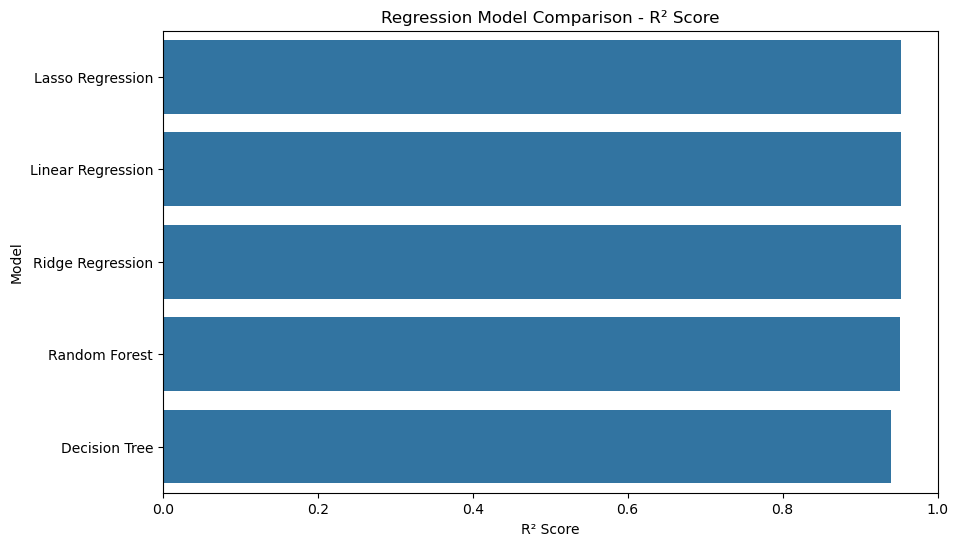

In [51]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="R2 Score",
    y="Model"
)

plt.title("Regression Model Comparison - R² Score")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.show()

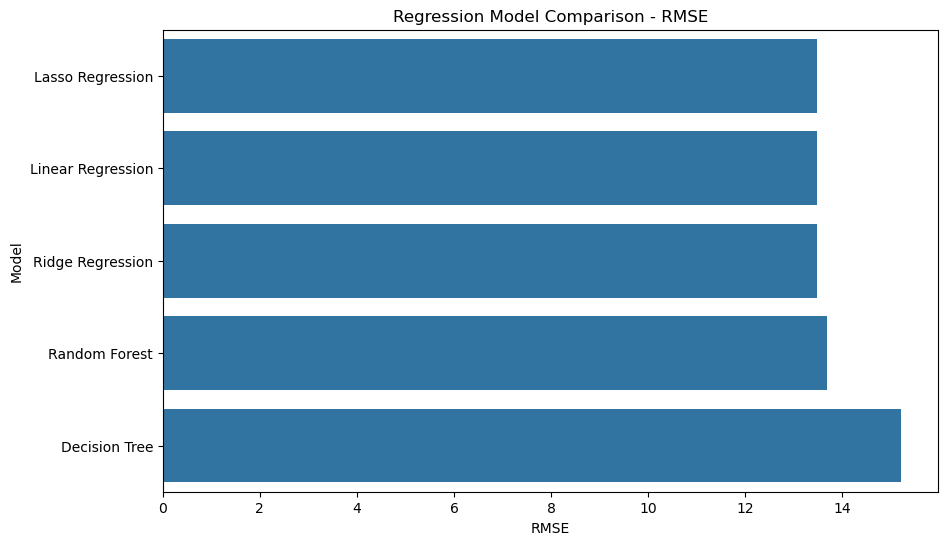

In [52]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="RMSE",
    y="Model"
)

plt.title("Regression Model Comparison - RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")

plt.show()

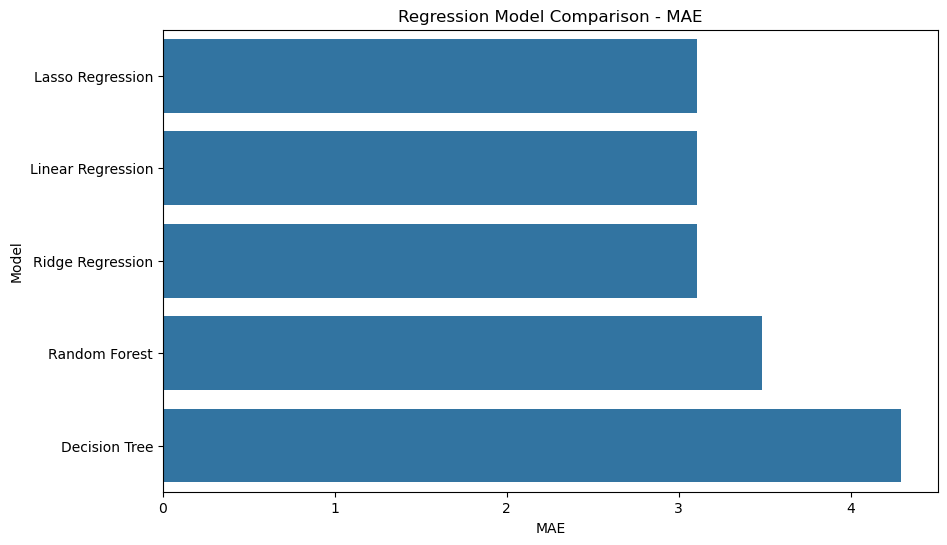

In [53]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="MAE",
    y="Model"
)

plt.title("Regression Model Comparison - MAE")
plt.xlabel("MAE")
plt.ylabel("Model")

plt.show()

In [54]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print(
    "Best Model:",
    best_model_name
)

Best Model: Lasso Regression


In [55]:
best_predictions = best_model.predict(
    X_test
)

comparison = pd.DataFrame({
    "Actual Revenue": y_test.values,
    "Predicted Revenue": best_predictions
})

comparison.head(20)

,Actual Revenue,Predicted Revenue
0,352.853521,352.895914
1,341.983789,342.188570
2,204.586883,204.470256
3,176.835670,176.510679
4,270.842839,270.900791
5,287.477455,287.620587
6,259.938374,260.206962
7,261.089317,261.498142
8,275.035544,275.182540
9,307.006351,307.241109


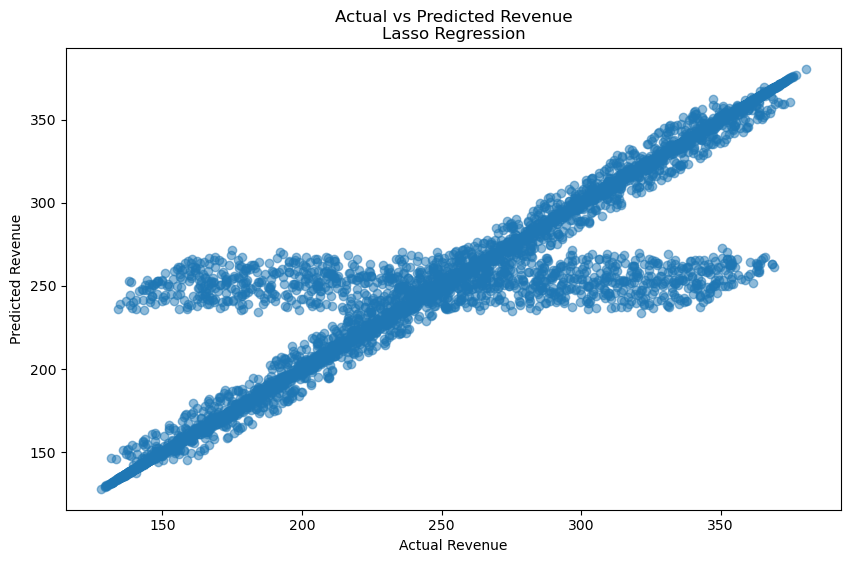

In [56]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")

plt.title(
    f"Actual vs Predicted Revenue\n{best_model_name}"
)

plt.show()

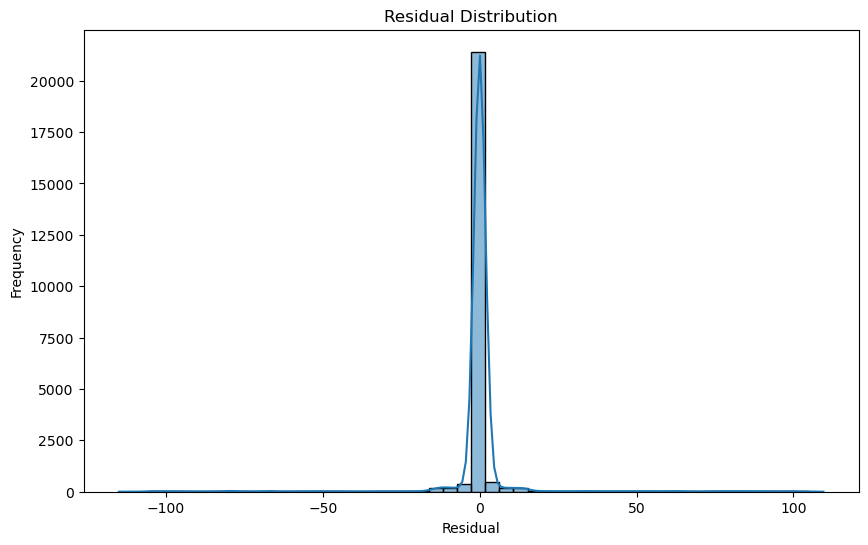

In [57]:
residuals = (
    y_test -
    best_predictions
)

plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

In [58]:
import joblib
import os

model_path = os.path.join(
    os.getcwd(),
    "model.pkl"
)

joblib.dump(
    best_model,
    model_path
)

print("New model.pkl created successfully!")
print("Saved at:", "C:\\Users\\ABHISHEK\\Documents\\Data Science\\CONTENT MONETIZATION MODELER_project")

New model.pkl created successfully!
Saved at: C:\Users\ABHISHEK\Documents\Data Science\CONTENT MONETIZATION MODELER_project


In [59]:
import os

comparison_path = os.path.join(
    os.getcwd(),
    "model_comparison.csv"
)

results_df.to_csv(
    comparison_path,
    index=False
)

print("Model comparison saved successfully!")
print("Saved at:", "C:\\Users\\ABHISHEK\\Documents\\Data Science\\CONTENT MONETIZATION MODELER_project")

Model comparison saved successfully!
Saved at: C:\Users\ABHISHEK\Documents\Data Science\CONTENT MONETIZATION MODELER_project


In [60]:
import os

cleaned_data_path = os.path.join(
    os.getcwd(),
    "cleaned_youtube_revenue_data.csv"
)

df.to_csv(
    cleaned_data_path,
    index=False
)

print("Cleaned dataset saved successfully!")
print("Saved at:",  "C:\\Users\\ABHISHEK\\Documents\\Data Science\\CONTENT MONETIZATION MODELER_project")

Cleaned dataset saved successfully!
Saved at: C:\Users\ABHISHEK\Documents\Data Science\CONTENT MONETIZATION MODELER_project


In [61]:
import sklearn
print(sklearn.__version__)

1.7.2
